# Assignment 04 — House Price

## A–C. Bài toán, dữ liệu và preprocessing

Notebook đã execute này nối toán học → NumPy from scratch → PyTorch → TensorFlow/Keras, so sánh Basic/Improved trên parity và chạy Improved full-scale.

Không xem vector one-hot 61 chiều của A03 là chuỗi locality. Sáu field state, status, acre_lot, house_size, bed, bath được biểu diễn thành 6 vị trí × 8 chiều; split theo property group; output tuyến tính.

Preprocessing/vocabulary chỉ fit train; cùng immutable split, initialization, Adam (lr=1e-3), batch order, tối đa 20 epochs, patience=3. Test không tham gia chọn kiến trúc.

### Mục đích của cell

Nạp metadata và output thực tế đã lưu. Cell chỉ đọc artifact, không split hoặc huấn luyện lại.

In [1]:
from pathlib import Path
import json, inspect
import numpy as np
import pandas as pd
from IPython.display import Image, display
HERE=Path.cwd().resolve()
ROOT=next((p for p in (HERE,*HERE.parents) if (p/'src/assignment04').exists()), None)
assert ROOT is not None, 'Không tìm thấy repository root'
META=json.loads((ROOT/'results/assignment04/manifests/house_preprocessing.json').read_text(encoding='utf-8'))
PARITY=pd.read_csv(ROOT/'results/assignment04/parity/house/parity_results.csv')
ARCH=pd.read_csv(ROOT/'results/assignment04/parity/house/architecture_comparison.csv')
FULL=pd.read_csv(ROOT/'results/assignment04/full_scale/house/full_results.csv')
HISTORY=pd.read_csv(ROOT/'results/assignment04/full_scale/house/training_history.csv')
print({'task':'house','selected':'improved','parity_runs':len(PARITY),'full_runs':len(FULL)})

{'task': 'house', 'selected': 'improved', 'parity_runs': 6, 'full_runs': 2}


### Phân tích kết quả

Đã đọc 6 parity validation runs và đúng 2 full-scale Improved runs (PyTorch, TensorFlow). Không có full NumPy run.

### Mục đích của cell

Kiểm tra số dòng master và preprocessing train-only để phát hiện sai split/leakage trước metric.

In [2]:
display(pd.DataFrame(META['splits']).T); print('fit_split =',META['fit_split'])

,master_rows,parity_rows,target_quantiles_usd
test,60000,10000,"{'0.0': 1.0, '0.25': 165000.0, '0.5': 325000.0..."
train,280000,40000,"{'0.0': 1.0, '0.25': 165000.0, '0.5': 325000.0..."
validation,60000,10000,"{'0.0': 1.0, '0.25': 165000.0, '0.5': 325000.0..."


fit_split = master_train_only


### Phân tích kết quả

Master split đúng train=280,000, validation=60,000, test=60,000. Group-aware split có 392,384 groups, largest=19, zero overlap=True.

## D–E. Toán học CNN và tensor shapes

Cross-correlation 1D: $z_{b,o,t}=b_o+\sum_c\sum_j W_{o,c,j}x_{b,c,t+j-p}$. Kernel trượt tạo local connectivity và weight sharing. ReLU $a=\max(0,z)$; max-pooling giữ cực đại cục bộ; dense tạo logits/giá trị hồi quy. Backprop dùng chain rule qua Dense → GlobalMaxPool → Conv; Adam cập nhật parameter từ moment bậc một/hai.

Ví dụ lecture `x=[2,1,3,4,2]`, `k=[0.5,-1,0.5]`: biểu thức số đầu tiên cho **1.5**; implementation/tests theo phép tính trực tiếp, không ép thành 1.

Input: `[B,8,6]`.

| Kiến trúc | Dòng tensor sau input |
|---|---|
| Basic | Conv1 `[B,8,L]` → Conv2 `[B,16,L]` → MaxPool `[B,16,L/2]` → GlobalMax `[B,16]` → Output |
| Improved | Conv1 `[B,8,L]` → Conv2 `[B,16,L]` → MaxPool → Conv3 `[B,32,L/2]` → GlobalMax `[B,32]` → Hidden `[B,16]` → Output |

Basic có 3 và Improved có 5 trainable conv/dense transformations; ReLU/pooling không tính là trainable layer. Field encoder có 536 tham số và được tính trong tổng tham số.

### Mục đích của cell

Tính sliding window và in đúng source cốt lõi/model task-specific để kiểm tra forward, gradient và update.

In [3]:
x=np.array([2,1,3,4,2.]); k=np.array([.5,-1,.5]); print('hand convolution:',[x[i:i+3]@k for i in range(3)])
from src.assignment04.scratch_layers import Conv1D, ReLU, MaxPool1D, Dense
from src.assignment04.scratch_losses import MSELoss
from src.assignment04.scratch_optim import Adam
from src.assignment04.scratch_models import ScratchHouseCNN, ScratchHouseFieldEncoder
from src.assignment04.torch_models import TorchHouseCNN, TorchHouseFieldEncoder
from src.assignment04.tensorflow_models import TFHouseCNN, TFHouseFieldEncoder
print('--- Conv1D forward/backward (NumPy) ---')
print(inspect.getsource(Conv1D.forward)); print(inspect.getsource(Conv1D.backward))
print('--- ReLU, pooling, dense, loss, Adam ---')
for obj in [ReLU, MaxPool1D.forward, MaxPool1D.backward, Dense.backward, MSELoss.forward, MSELoss.backward, Adam.step]:
    print(inspect.getsource(obj))
print('--- Model/encoder thực sự dùng cho house ---')
for obj in [ScratchHouseFieldEncoder.forward, ScratchHouseCNN.forward, TorchHouseFieldEncoder.forward, TorchHouseCNN.forward, TFHouseFieldEncoder.call, TFHouseCNN.call]:
    print(inspect.getsource(obj))

hand convolution: [np.float64(1.5), np.float64(-0.5), np.float64(-1.5)]


--- Conv1D forward/backward (NumPy) ---
    def forward(self, x):
        x = np.asarray(x)
        if x.ndim != 3 or x.shape[1] != self.weight.shape[1]:
            raise ValueError("Conv1D input must have shape [B, C_in, L]")
        x_pad = np.pad(x, ((0, 0), (0, 0), (self.pad, self.pad)))
        windows = np.lib.stride_tricks.sliding_window_view(x_pad, self.kernel_size, axis=2)
        output = np.einsum("bclk,ock->bol", windows, self.weight) + self.bias[None, :, None]
        self._cache = (x.shape, x_pad, windows)
        return output

    def backward(self, grad_output):
        if self._cache is None:
            raise RuntimeError("forward must be called before backward")
        original_shape, x_pad, windows = self._cache
        grad_output = np.asarray(grad_output)
        self.grad_weight[...] = np.einsum("bol,bclk->ock", grad_output, windows)
        self.grad_bias[...] = grad_output.sum(axis=(0, 2))
        grad_pad = np.zeros_like(x_pad)
        # Each kernel tap con

### Phân tích kết quả

Output tay là `[1.5, -0.5, -1.5]`. Source cho thấy NumPy tự tạo window, chia sẻ kernel, lưu mask/argmax cho backward, truyền gradient qua embedding/field encoder và Adam cập nhật ndarray; scratch không gọi convolution Torch/TF/SciPy.

## F–K. NumPy verification, Basic/Improved, PyTorch và TensorFlow

Finite-difference kiểm tra gradient; canonical NumPy weights được transpose sang layout từng framework. Parity giữ cùng dữ liệu, batch order và objective. House dùng MSE trên standardized log1p(price), báo metric USD; classification dùng 2 logits và cross-entropy.

### Mục đích của cell

Hiển thị numerical parity và aggregate validation dùng chọn Basic/Improved.

In [4]:
VERIFY=json.loads((ROOT/'results/assignment04/parity/verification.json').read_text(encoding='utf-8')); display(VERIFY); display(ARCH)

{'artifact_checks': {'all_figures_nonempty': True,
  'all_history_losses_finite': True,
  'all_notebooks_executed_without_errors': True,
  'all_numeric_outputs_finite_where_present': True,
  'all_run_keys_once': True,
  'comments_artifact_checksums_verified': True,
  'diabetes_manifest_verified': True,
  'figures': {'comments_parity_loss_curves.png': {'bytes': 129629,
    'exists': True},
   'diabetes_parity_loss_curves.png': {'bytes': 105501, 'exists': True},
   'house_parity_loss_curves.png': {'bytes': 107518, 'exists': True}},
  'house_manifest_verified': True,
  'nonselected_test_metrics_absent': True,
  'notebooks': {'01_diabetes_cnn.ipynb': {'cells': 35,
    'code_cells': 9,
    'error_outputs': 0,
    'executed_code_cells': 9},
   '02_house_price_cnn.ipynb': {'cells': 35,
    'code_cells': 9,
    'error_outputs': 0,
    'executed_code_cells': 9},
   '03_comments_cnn.ipynb': {'cells': 35,
    'code_cells': 9,
    'error_outputs': 0,
    'executed_code_cells': 9}},
  'parameter_co

,architecture,mean_validation_rmse,mean_validation_mae
0,improved,902700.876199,259800.276042
1,basic,905589.303229,263800.114583


### Phân tích kết quả

Gradient/parity trong tolerance đã khóa. improved: mean validation RMSE=$902,701, basic: mean validation RMSE=$905,589. Improved được chọn trước full-scale; Basic không bị mở test lặp.

### Mục đích của cell

Hiển thị đầy đủ metric validation parity và test chỉ của architecture đã chọn.

In [5]:
val_cols=['architecture','implementation','parameter_count','best_epoch','training_seconds']+[c for c in PARITY if c.startswith('validation_')]; display(PARITY[val_cols]); test_cols=['implementation']+[c for c in PARITY if c.startswith('test_')]; display(PARITY.loc[PARITY.architecture.eq('improved'),test_cols])

,architecture,implementation,parameter_count,best_epoch,training_seconds,validation_samples,validation_loss,validation_mae,validation_rmse,validation_r2
0,basic,scratch,1153,7,165.143485,10000,0.583200,264113.906250,905522.337306,0.219157
1,basic,pytorch,1153,7,58.174078,10000,0.583187,263975.437500,906250.196553,0.217901
2,basic,tensorflow,1153,8,56.513360,10000,0.579259,263311.000000,904995.375829,0.220065
3,improved,scratch,3249,4,250.794413,10000,0.569778,261321.187500,900359.060535,0.228036
4,improved,pytorch,3249,4,25.533897,10000,0.571099,261521.656250,899229.107002,0.229973
5,improved,tensorflow,3249,7,34.068053,10000,0.559683,256557.984375,908514.461058,0.213988


,implementation,test_samples,test_loss,test_mae,test_rmse,test_r2
3,scratch,10000,0.614731,282060.3125,1.063024e+06,0.267218
4,pytorch,10000,0.616251,282328.4375,1.063063e+06,0.267165
5,tensorflow,10000,0.604294,279610.7500,1.090907e+06,0.228272


### Phân tích kết quả

Validation là cơ sở chọn kiến trúc. Test của Basic để trống có chủ ý; chỉ Improved được mở parity-test. Sai khác sau training có thể do floating-point kernels/optimizer dù initial forward đã parity.

## L–N. Full-scale Improved CNN

Không chạy full NumPy scratch vì mục tiêu pedagogical đã hoàn thành ở parity. PyTorch/TensorFlow dùng toàn bộ frozen train/validation và cùng full master-test. Parity-test nằm trong master-test nên full test không phải holdout hoàn toàn mới; không tune sau test.

### Mục đích của cell

Hiển thị best epoch, thời gian và đầy đủ validation/test metrics thực tế của 2 full runs.

In [6]:
cols=['implementation','train_samples','validation_samples','test_samples','parameter_count','best_epoch','epochs_ran','training_seconds']+[c for c in FULL if c.startswith('validation_') or c.startswith('test_')]; display(FULL[cols])

,implementation,train_samples,validation_samples,test_samples,parameter_count,best_epoch,epochs_ran,training_seconds,validation_samples,test_samples,test_scope,validation_loss,validation_mae,validation_rmse,validation_r2,test_loss,test_mae,test_rmse,test_r2
0,pytorch,280000,60000,60000,3249,10,13,309.735619,60000,60000,complete frozen master test (includes prior pa...,235.850418,251286.770411,1.240241e+06,0.271044,0.461620,252719.439454,1.290996e+06,0.173660
1,tensorflow,280000,60000,60000,3249,10,13,220.349955,60000,60000,complete frozen master test (includes prior pa...,1465.293091,254833.809112,1.320887e+06,0.173161,0.484165,255105.616753,1.291741e+06,0.172705


### Phân tích kết quả

PyTorch: MAE=$252,719, RMSE=$1,290,996, R²=0.1737; TensorFlow: MAE=$255,106, RMSE=$1,291,741, R²=0.1727. Theo RMSE, PyTorch thấp hơn; metric đã inverse-transform về USD.

### Mục đích của cell

Hiển thị loss curves và confusion matrix/metric plot từ đúng history/full results.

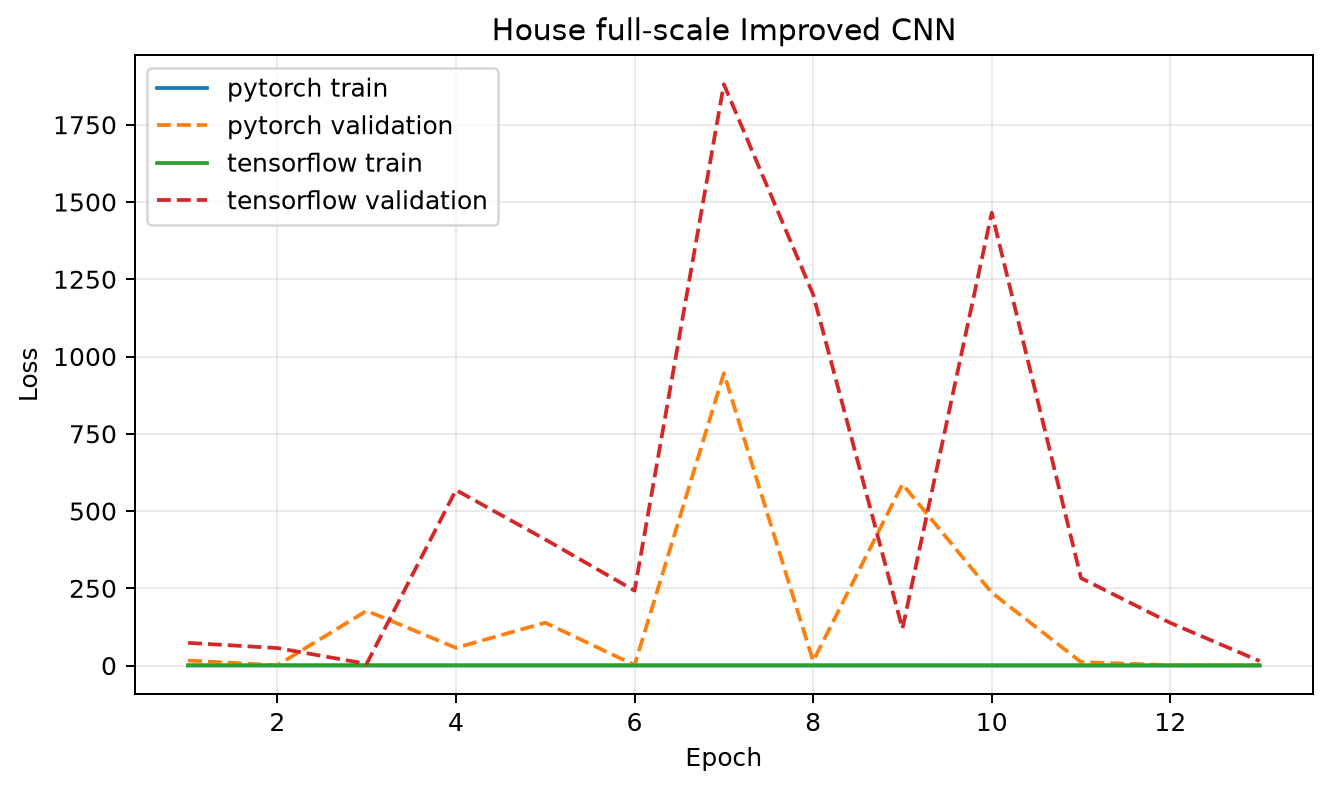

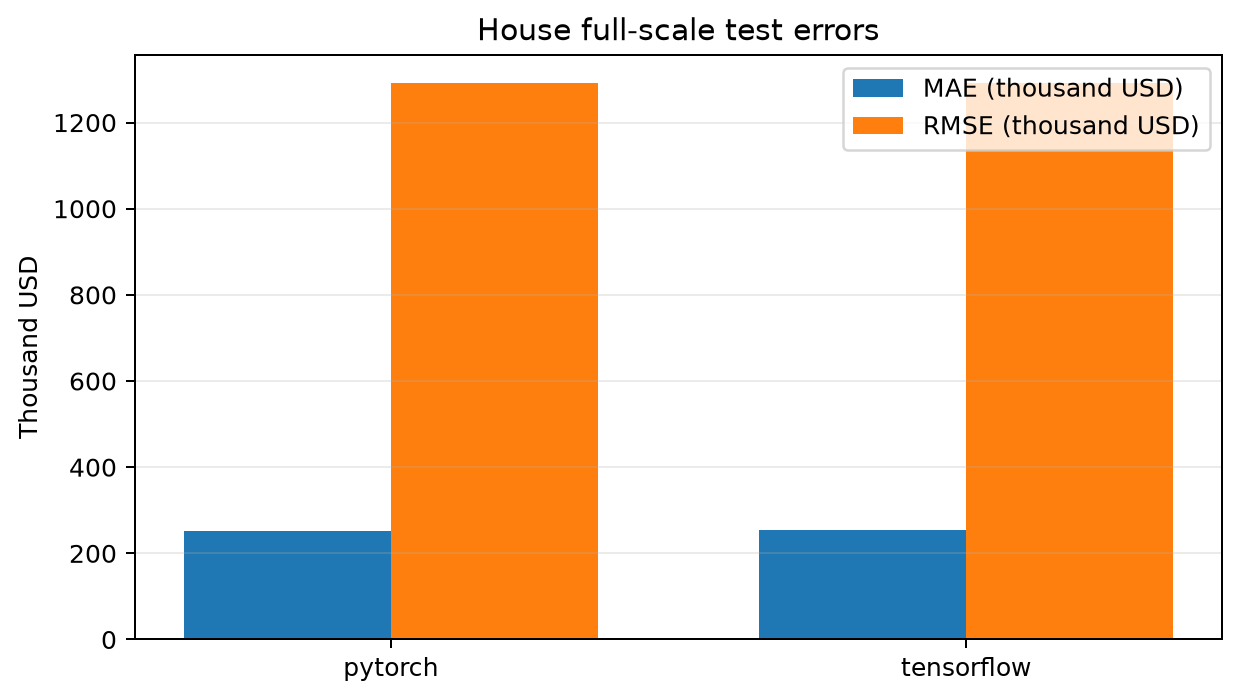

In [7]:
display(Image(filename=str(ROOT/'figures/assignment04/house_full_loss_curves.png'))); display(Image(filename=str(ROOT/'figures/assignment04/house_full_metrics.png')))

### Phân tích kết quả

Gap loss epoch cuối: pytorch: val−train=+0.7453, tensorflow: val−train=+14.1944. Early stopping chọn checkpoint theo validation F1 rồi loss (classification), hoặc RMSE rồi MAE (House); checkpoint tốt nhất được dùng cho test.

## O–Q. So sánh, diễn giải, kết luận và giới hạn

**Basic vs Improved:** improved: mean validation RMSE=$902,701, basic: mean validation RMSE=$905,589; Improved được chọn từ parity validation, không phải full test.

**PyTorch vs TensorFlow full-scale:** PyTorch: MAE=$252,719, RMSE=$1,290,996, R²=0.1737; TensorFlow: MAE=$255,106, RMSE=$1,291,741, R²=0.1727. Theo RMSE, PyTorch thấp hơn; metric đã inverse-transform về USD.

Kết quả là một seed và CPU. Với Diabetes/House, locality là cấu trúc giảng dạy nên không kết luận CNN tự nhiên tối ưu cho tabular data. House nhạy outlier trên USD dù training dùng log-target. Comments có locality token hợp lý hơn nhưng vẫn chịu vocabulary hữu hạn, OOV, truncation và embedding học từ đầu. Timing phụ thuộc backend/CPU và không đồng nghĩa chất lượng.